In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
import category_encoders as ce

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
df_1 = pd.read_csv(r"data\Fraudulent_E-Commerce_Transaction_Data.csv")
df_2 = pd.read_csv(r"data\Fraudulent_E-Commerce_Transaction_Data_2.csv")

In [3]:
df = pd.concat([df_1, df_2], ignore_index=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1496586 entries, 0 to 1496585
Data columns (total 16 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Transaction ID      1496586 non-null  object 
 1   Customer ID         1496586 non-null  object 
 2   Transaction Amount  1496586 non-null  float64
 3   Transaction Date    1496586 non-null  object 
 4   Payment Method      1496586 non-null  object 
 5   Product Category    1496586 non-null  object 
 6   Quantity            1496586 non-null  int64  
 7   Customer Age        1496586 non-null  int64  
 8   Customer Location   1496586 non-null  object 
 9   Device Used         1496586 non-null  object 
 10  IP Address          1496586 non-null  object 
 11  Shipping Address    1496586 non-null  object 
 12  Billing Address     1496586 non-null  object 
 13  Is Fraudulent       1496586 non-null  int64  
 14  Account Age Days    1496586 non-null  int64  
 15  Transaction Hou

In [4]:
df.head(5)

,Transaction ID,Customer ID,Transaction Amount,Transaction Date,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Shipping Address,Billing Address,Is Fraudulent,Account Age Days,Transaction Hour
0,15d2e414-8735-46fc-9e02-80b472b2580f,d1b87f62-51b2-493b-ad6a-77e0fe13e785,58.09,2024-02-20 05:58:41,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,Unit 8934 Box 0058\nDPO AA 05437,Unit 8934 Box 0058\nDPO AA 05437,0,30,5
1,0bfee1a0-6d5e-40da-a446-d04e73b1b177,37de64d5-e901-4a56-9ea0-af0c24c069cf,389.96,2024-02-25 08:09:45,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,"634 May Keys\nPort Cherylview, NV 75063","634 May Keys\nPort Cherylview, NV 75063",0,72,8
2,e588eef4-b754-468e-9d90-d0e0abfc1af0,1bac88d6-4b22-409a-a06b-425119c57225,134.19,2024-03-18 03:42:55,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,"16282 Dana Falls Suite 790\nRothhaven, IL 15564","16282 Dana Falls Suite 790\nRothhaven, IL 15564",0,63,3
3,4de46e52-60c3-49d9-be39-636681009789,2357c76e-9253-4ceb-b44e-ef4b71cb7d4d,226.17,2024-03-16 20:41:31,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,"828 Strong Loaf Apt. 646\nNew Joshua, UT 84798","828 Strong Loaf Apt. 646\nNew Joshua, UT 84798",0,124,20
4,074a76de-fe2d-443e-a00c-f044cdb68e21,45071bc5-9588-43ea-8093-023caec8ea1c,121.53,2024-01-15 05:08:17,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,"29799 Jason Hills Apt. 439\nWest Richardtown, ...","29799 Jason Hills Apt. 439\nWest Richardtown, ...",0,158,5


In [5]:
df.count

<bound method DataFrame.count of                                Transaction ID  \
0        15d2e414-8735-46fc-9e02-80b472b2580f   
1        0bfee1a0-6d5e-40da-a446-d04e73b1b177   
2        e588eef4-b754-468e-9d90-d0e0abfc1af0   
3        4de46e52-60c3-49d9-be39-636681009789   
4        074a76de-fe2d-443e-a00c-f044cdb68e21   
...                                       ...   
1496581  d8b7171f-bdd9-479c-b98b-396c621aebfe   
1496582  0fd12cf3-c641-4499-8de1-15dc4555cb0c   
1496583  649680d3-a684-44cb-95bf-9b454c3aa86d   
1496584  c10dbb08-28fc-4ec1-9850-d4e98d2b9640   
1496585  23e3c107-f2fc-48c2-abbc-7b809bf6f102   

                                  Customer ID  Transaction Amount  \
0        d1b87f62-51b2-493b-ad6a-77e0fe13e785               58.09   
1        37de64d5-e901-4a56-9ea0-af0c24c069cf              389.96   
2        1bac88d6-4b22-409a-a06b-425119c57225              134.19   
3        2357c76e-9253-4ceb-b44e-ef4b71cb7d4d              226.17   
4        45071bc5-9588-43ea-8093-

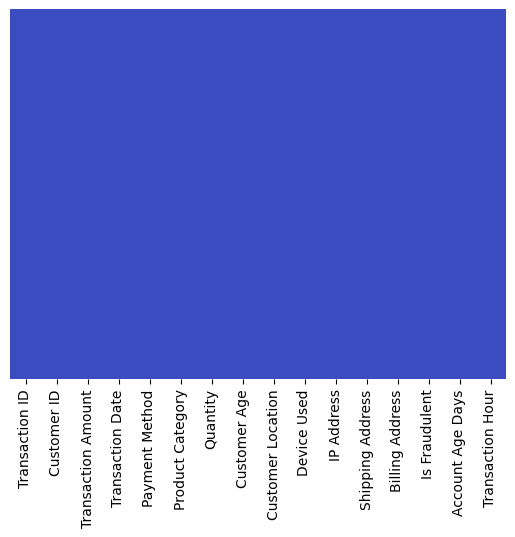

In [ ]:
sns.heatmap(df.isnull(), yticklabels = False, cbar = False, cmap="coolwarm")
plt.show()

In [6]:
df.describe()

,Transaction Amount,Quantity,Customer Age,Is Fraudulent,Account Age Days,Transaction Hour
count,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06,1.496586e+06
mean,2.268093e+02,3.000235e+00,3.451284e+01,5.015415e-02,1.796308e+02,1.128663e+01
std,2.705831e+02,1.414814e+00,1.000323e+01,2.182630e-01,1.068726e+02,6.976067e+00
min,1.000000e+01,1.000000e+00,-1.600000e+01,0.000000e+00,1.000000e+00,0.000000e+00
25%,6.862000e+01,2.000000e+00,2.800000e+01,0.000000e+00,8.600000e+01,5.000000e+00
50%,1.517600e+02,3.000000e+00,3.500000e+01,0.000000e+00,1.790000e+02,1.100000e+01
75%,2.960500e+02,4.000000e+00,4.100000e+01,0.000000e+00,2.720000e+02,1.700000e+01
max,1.270175e+04,5.000000e+00,8.600000e+01,1.000000e+00,3.650000e+02,2.300000e+01


In [ ]:
df.columns

Index(['Transaction ID', 'Customer ID', 'Transaction Amount',
       'Transaction Date', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'IP Address',
       'Shipping Address', 'Billing Address', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour'],
      dtype='object')

In [ ]:
print(len(df.columns))

16


In [ ]:
# plt.figure(figsize=(10, 50))

# for i in range(len(df.columns)):
#     plt.subplot(17, 1, i + 1)
#     sns.histplot(df[df.columns[i]], kde=True, color="g")
#     plt.title(df.columns[i])

# plt.tight_layout()
# plt.show()

In [6]:
# Xử lý ngày tháng năm giao dịch
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

df['Transaction_Year'] = df['Transaction Date'].dt.year
df['Transaction_Month'] = df['Transaction Date'].dt.month
df['Transaction_Day'] = df['Transaction Date'].dt.day
# df['Transaction_Hour'] = df['Transaction Date'].dt.hour    # loại vì đã có transaction_hour
df['Transaction_Minute'] = df['Transaction Date'].dt.minute
df['Transaction_Second'] = df['Transaction Date'].dt.second
df['Transaction_DayOfWeek'] = df['Transaction Date'].dt.dayofweek
df['Is_Weekend'] = df['Transaction_DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

df.drop(columns=["Transaction Date"], inplace=True)

In [8]:
df[['Transaction_Year', 'Transaction_Month', 'Transaction_Day',
     'Transaction_DayOfWeek', 'Is_Weekend']].head()


,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_DayOfWeek,Is_Weekend
0,2024,2,20,1,0
1,2024,2,25,6,1
2,2024,3,18,0,0
3,2024,3,16,5,1
4,2024,1,15,0,0


In [7]:
cols_to_drop = [
    "Transaction ID",
    "Customer ID",
    "Shipping Address",
    "Billing Address"
]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [8]:
df.head()

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,IP Address,Is Fraudulent,Account Age Days,Transaction Hour,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Minute,Transaction_Second,Transaction_DayOfWeek,Is_Weekend
0,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,212.195.49.198,0,30,5,2024,2,20,58,41,1,0
1,389.96,debit card,electronics,2,40,East Timothy,desktop,208.106.249.121,0,72,8,2024,2,25,9,45,6,1
2,134.19,PayPal,home & garden,2,22,Davismouth,tablet,76.63.88.212,0,63,3,2024,3,18,42,55,0,0
3,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,207.208.171.73,0,124,20,2024,3,16,41,31,5,1
4,121.53,bank transfer,clothing,2,51,South Nicole,tablet,190.172.14.169,0,158,5,2024,1,15,8,17,0,0


In [9]:
import ipaddress

def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except:
        return None

df['IP_Int'] = df['IP Address'].apply(ip_to_int)
df.drop(columns=["IP Address"], inplace=True)

In [13]:
df.head()

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,Is Fraudulent,Account Age Days,Transaction Hour,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Minute,Transaction_Second,Transaction_DayOfWeek,Is_Weekend,IP_Int
0,58.09,bank transfer,electronics,1,17,Amandaborough,tablet,0,30,5,2024,2,20,58,41,1,0,3569562054
1,389.96,debit card,electronics,2,40,East Timothy,desktop,0,72,8,2024,2,25,9,45,6,1,3496671609
2,134.19,PayPal,home & garden,2,22,Davismouth,tablet,0,63,3,2024,3,18,42,55,0,0,1279219924
3,226.17,bank transfer,clothing,5,31,Lynnberg,desktop,0,124,20,2024,3,16,41,31,5,1,3486559049
4,121.53,bank transfer,clothing,2,51,South Nicole,tablet,0,158,5,2024,1,15,8,17,0,0,3198946985


In [10]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest

In [11]:
label_cols = ['Payment Method', 'Product Category', 'Customer Location', 'Device Used']
le = LabelEncoder()

for col in label_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
df

,Transaction Amount,Payment Method,Product Category,Quantity,Customer Age,Customer Location,Device Used,Is Fraudulent,Account Age Days,Transaction Hour,Transaction_Year,Transaction_Month,Transaction_Day,Transaction_Minute,Transaction_Second,Transaction_DayOfWeek,Is_Weekend,IP_Int
0,58.09,1,1,1,17,663,2,0,30,5,2024,2,20,58,41,1,0,3569562054
1,389.96,3,1,2,40,17355,0,0,72,8,2024,2,25,9,45,6,1,3496671609
2,134.19,0,3,2,22,6791,2,0,63,3,2024,3,18,42,55,0,0,1279219924
3,226.17,1,0,5,31,36823,0,0,124,20,2024,3,16,41,31,5,1,3486559049
4,121.53,1,0,2,51,82916,2,0,158,5,2024,1,15,8,17,0,0,3198946985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496581,53.73,0,4,5,32,72506,2,0,363,16,2024,1,26,25,5,4,0,2908865920
1496582,47.42,2,0,4,41,39809,0,0,296,17,2024,2,25,3,26,6,1,2245924400
1496583,1045.23,1,2,1,9,16552,2,0,329,23,2024,3,28,46,47,3,0,3464883624
1496584,34.25,3,3,2,39,33036,1,0,347,11,2024,2,9,29,18,4,0,281840002


In [13]:
target = "Is Fraudulent"
X_sample = df.drop(columns=[target])
y_sample = df[target]


In [14]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # chọn 5% giao dịch bất thường
    random_state=42
)

model.fit(X_sample)
df['Anomaly_Score'] = model.decision_function(X_sample)
df['Anomaly'] = model.predict(X_sample)
df['Anomaly'] = df['Anomaly'].map({1: 0, -1: 1})  # 1: Anomaly, 0: Normal

In [15]:
anomalies = df[df['Anomaly'] == 1]
print(anomalies)

         Transaction Amount  Payment Method  Product Category  Quantity  \
6                     92.88               0                 4         2   
10                   633.39               0                 4         5   
23                   199.02               3                 4         4   
53                    65.03               3                 4         2   
54                    22.93               2                 4         1   
...                     ...             ...               ...       ...   
1496521              783.54               3                 0         1   
1496525               60.24               3                 2         1   
1496542              533.91               3                 4         5   
1496565              599.12               0                 2         2   
1496583             1045.23               1                 2         1   

         Customer Age  Customer Location  Device Used  Is Fraudulent  \
6                  14      

In [16]:
#print annomaly score in ascending order
df[['Anomaly_Score']].sort_values(by='Anomaly_Score', ascending=True)

,Anomaly_Score
247133,-0.086463
1431989,-0.079296
1056793,-0.079114
1037496,-0.077279
1306728,-0.076319
...,...
1209863,0.121740
782333,0.122175
462418,0.122291
131136,0.125167


In [17]:
#so sánh kết quả bất thường với nhãn thực tế
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_sample, df['Anomaly'], digits=4))

              precision    recall  f1-score   support

           0     0.9560    0.9561    0.9560   1421526
           1     0.1665    0.1660    0.1662     75060

    accuracy                         0.9165   1496586
   macro avg     0.5612    0.5610    0.5611   1496586
weighted avg     0.9164    0.9165    0.9164   1496586



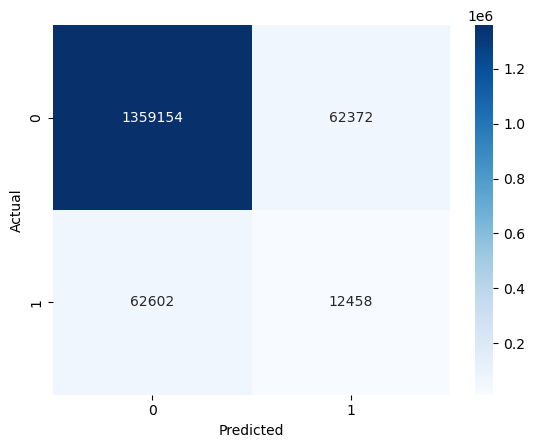

In [18]:
cm = confusion_matrix(y_sample, df['Anomaly'])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
normal = df[df['Anomaly'] == 0]

In [38]:
print(df.columns)

Index(['Transaction Amount', 'Payment Method', 'Product Category', 'Quantity',
       'Customer Age', 'Customer Location', 'Device Used', 'Is Fraudulent',
       'Account Age Days', 'Transaction Hour', 'Transaction_Year',
       'Transaction_Month', 'Transaction_Day', 'Transaction_Minute',
       'Transaction_Second', 'Transaction_DayOfWeek', 'Is_Weekend', 'IP_Int',
       'Anomaly_Score', 'Anomaly'],
      dtype='object')


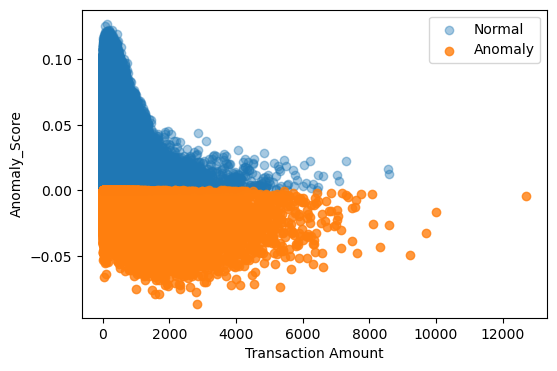

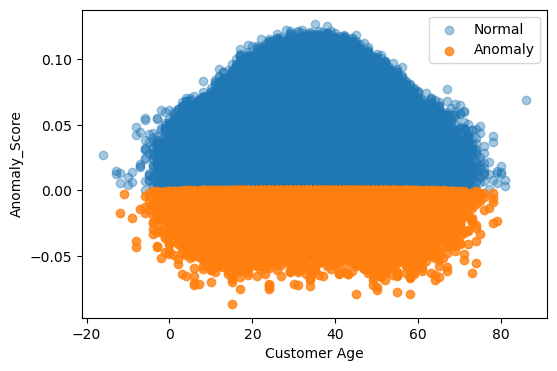

In [ ]:
# Chọn các cột numerical để plot
num_cols = [
    'Transaction Amount', 'Customer Age'
]

for x in num_cols:
    plt.figure(figsize=(6,4))
    plt.scatter(normal[x], normal['Anomaly_Score'], alpha=0.4, label='Normal')
    plt.scatter(anomalies[x], anomalies['Anomaly_Score'], alpha=0.8, label='Anomaly')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend()

plt.show()

In [30]:
def classify(row):
    y_true = row['Is Fraudulent']
    y_pred = row['Anomaly']

    if y_true == 1 and y_pred == 1:
        return "TP"   # Dự đoán đúng gian lận
    elif y_true == 0 and y_pred == 0:
        return "TN"   # Dự đoán đúng bình thường
    elif y_true == 0 and y_pred == 1:
        return "FP"   # Dự đoán sai (báo động giả)
    elif y_true == 1 and y_pred == 0:
        return "FN"   # Bỏ sót gian lận

df['Type'] = df.apply(classify, axis=1)

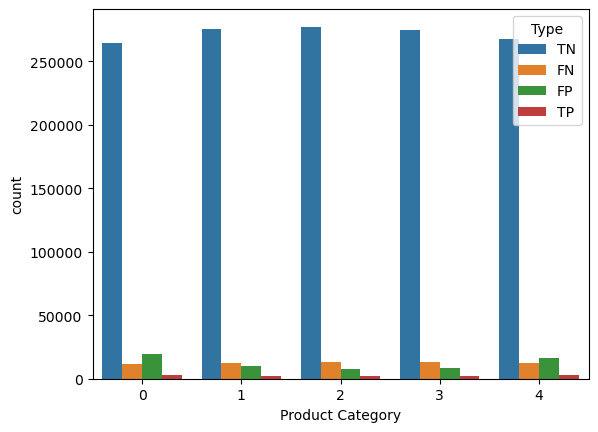

In [31]:
sns.countplot(data=df, x='Product Category', hue='Type')
plt.show()

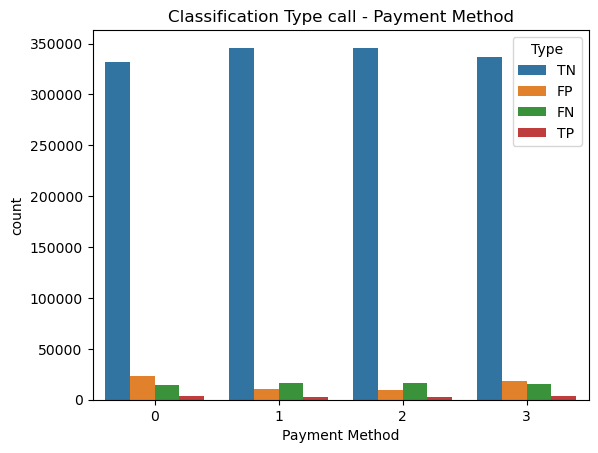

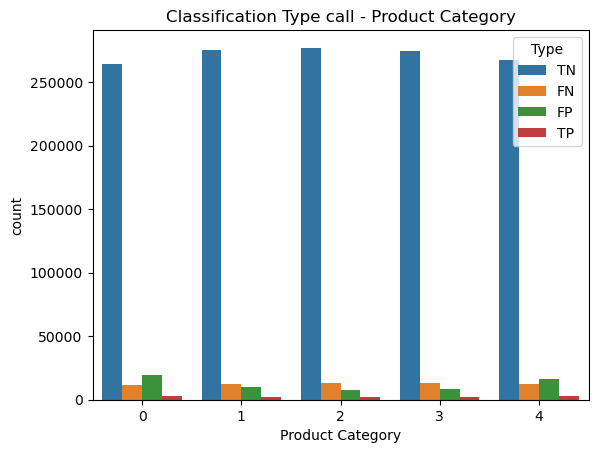

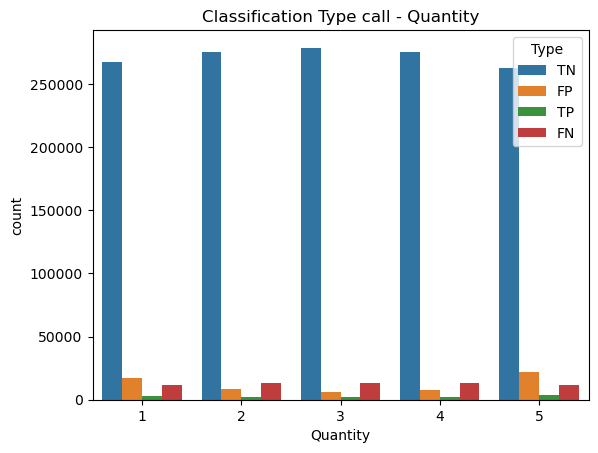

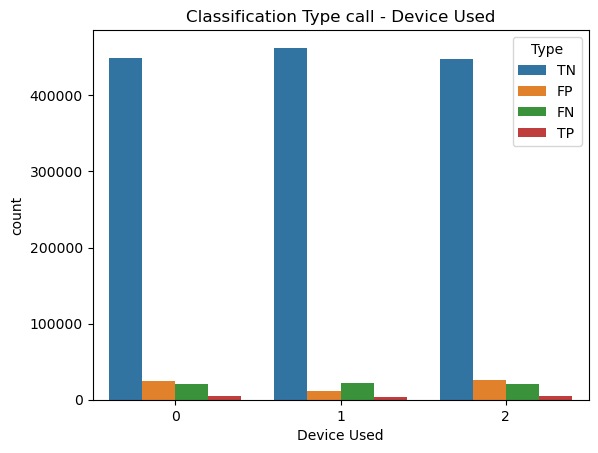

In [32]:
categorical_col = ['Payment Method', 'Product Category', 'Quantity','Device Used']

for col in categorical_col:
    sns.countplot(data=df, x=col, hue='Type')
    plt.title(f'Classification Type call - {col}')
    plt.show()

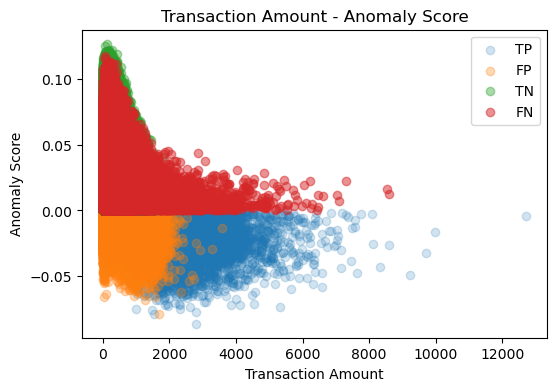

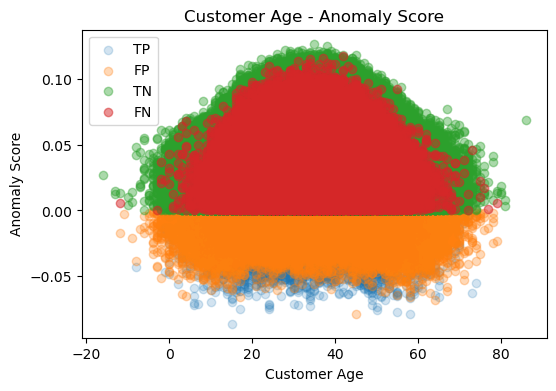

In [ ]:
num_cols = [
    'Transaction Amount',
    'Customer Age'
]

for x in num_cols:
    plt.figure(figsize=(6,4))

    plt.scatter(df[df['Type'] == 'TP'][x], df[df['Type'] == 'TP']['Anomaly_Score'], label='TP', alpha=0.2)
    plt.scatter(df[df['Type'] == 'FP'][x], df[df['Type'] == 'FP']['Anomaly_Score'], label='FP', alpha=0.3)
    plt.scatter(df[df['Type'] == 'TN'][x], df[df['Type'] == 'TN']['Anomaly_Score'], label='TN', alpha=0.4)
    plt.scatter(df[df['Type'] == 'FN'][x], df[df['Type'] == 'FN']['Anomaly_Score'], label='FN', alpha=0.5)
    plt.xlabel(x)
    plt.ylabel("Anomaly Score")
    plt.title(f"{x} - Anomaly Score")
    plt.legend()

plt.show()